In [1]:
import sys
sys.path.append('../../../../')

In [2]:
from CADETProcess.optimization import OptimizationProblem

optimization_problem = OptimizationProblem('single_objective')

[INFO 08-12 16:19:29] ax.storage.sqa_store.with_db_settings_base: Ax SQL storage initialized with SQLAlchemy 2.0.52


In [3]:
optimization_problem.add_variable('var_0', lb=0, ub=100)

RangedParameter(name='var_0', parameter_type=float, lb=0, ub=100)

In [4]:
print(optimization_problem.n_variables)
print(optimization_problem.variable_names)

1
['var_0']


In [5]:
def objective(x):
    return x**2

In [6]:
optimization_problem.add_objective(objective)

In [7]:
optimization_problem = OptimizationProblem('multi_objective')
optimization_problem.add_variable('x', lb=0, ub=10)
optimization_problem.add_variable('y', lb=-10, ub=10)

RangedParameter(name='y', parameter_type=float, lb=-10, ub=10)

In [8]:
import numpy as np

def objective_1(x):
    return x[0]**2 + x[1]**2

optimization_problem.add_objective(objective_1)

def objective_2(x):
    return (x[0] - 2)**2 + (x[1] - 2)**2

optimization_problem.add_objective(objective_2)

In [9]:
optimization_problem = OptimizationProblem('multi_objective')
optimization_problem.add_variable('x', lb=0, ub=10)
optimization_problem.add_variable('y', lb=-10, ub=10)

RangedParameter(name='y', parameter_type=float, lb=-10, ub=10)

In [10]:
def multi_objective(x):
    f_1 = x[0]**2 + x[1]**2
    f_2 = (x[0] - 2)**2 + (x[1] - 2)**2
    return np.hstack((f_1, f_2))

optimization_problem.add_objective(multi_objective, n_objectives=2)

In [11]:
optimization_problem.n_objectives

2

In [12]:
optimization_problem.evaluate_objectives([1, 1])

array([2., 2.])

In [13]:
optimization_problem.evaluate_objectives([[0, 1], [1, 1], [2, -1]])

array([[1., 5.],
       [2., 2.],
       [5., 9.]])

In [14]:
optimization_problem = OptimizationProblem('linear_constraints')

optimization_problem.add_variable('var_1')
optimization_problem.add_variable('var_2')

RangedParameter(name='var_2', parameter_type=float, lb=-inf, ub=inf)

In [15]:
optimization_problem.add_linear_constraint(['var_1', 'var_2'], [1, -1], 0)
optimization_problem.check_linear_constraints([5, 3])

False

In [16]:
optimization_problem = OptimizationProblem('nonlinear_constraints')
optimization_problem.add_variable('x', lb=0, ub=10)
optimization_problem.add_variable('y', lb=0, ub=10)

RangedParameter(name='y', parameter_type=float, lb=0, ub=10)

In [17]:
def nonlincon(x):
    return np.prod(x)

In [18]:
optimization_problem.add_nonlinear_constraint(nonlincon)

In [19]:
optimization_problem.evaluate_nonlinear_constraints([0.5, 0.5])

array([0.25])

In [20]:
optimization_problem.check_nonlinear_constraints([0.5, 0.5])

False

In [21]:
optimization_problem = OptimizationProblem('nonlinear_constraints')
optimization_problem.add_variable('x', lb=0, ub=10)
optimization_problem.add_variable('y', lb=0, ub=10)

RangedParameter(name='y', parameter_type=float, lb=0, ub=10)

In [22]:
optimization_problem.add_nonlinear_constraint(nonlincon, bounds=1)

In [23]:
optimization_problem.evaluate_nonlinear_constraints([0.5, 0.5])

array([0.25])

In [24]:
optimization_problem.evaluate_nonlinear_constraints_violation([0.5, 0.5])

array([-0.75])

In [25]:
optimization_problem.check_nonlinear_constraints([0.5, 0.5])

True

In [26]:
optimization_problem = OptimizationProblem('linear_constraints')

optimization_problem.add_variable('x_0', lb=-10, ub=10)
optimization_problem.add_variable('x_1', lb=-10, ub=10)

optimization_problem.add_linear_constraint(['x_0', 'x_1'], [-1, 1], 0)

In [27]:
optimization_problem.create_initial_values()

array([[ 8.93918964, -1.16206534]])

In [28]:
optimization_problem.get_chebyshev_center()

array([ 4.14213562, -4.14213562])

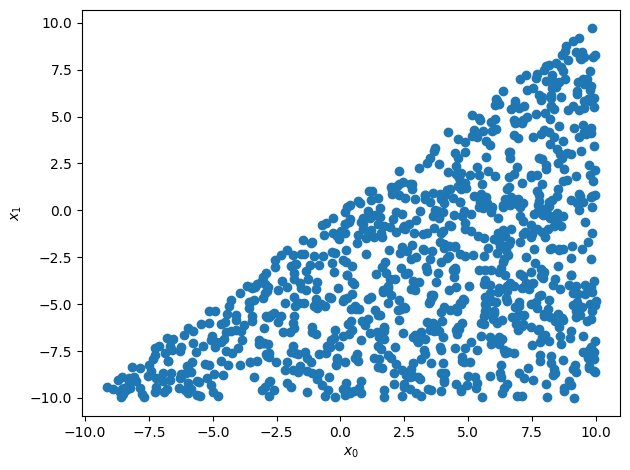

In [29]:
x = optimization_problem.create_initial_values(n_samples=1000)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(x[:, 0], x[:, 1])
ax.set_xlabel(r'$x_0$')
ax.set_ylabel(r'$x_1$')
fig.tight_layout()

In [30]:
def callback(results, individual, evaluation_object, callbacks_dir):
    print(results)
    print(individual.X, individual.metrics)
    print(evaluation_object)
    print(callbacks_dir)

In [31]:
optimization_problem.add_callback(callback)

In [32]:
import os
from glob import glob
from shutil import rmtree

path = os.getcwd()
pattern = os.path.join(path, "results_*")

for item in glob(pattern):
    if not os.path.isdir(item):
        continue
    rmtree(item)